In [1]:
import nltk
import pandas as pd
from nltk.corpus import reuters
from sklearn.feature_extraction.text import TfidfVectorizer

create datafram from nltk reuters and print first elements

In [2]:
nltk.download('reuters', download_dir='../../data/raw')

fileids = reuters.fileids()

categories = []
text = []

for file in fileids:
    categories.append(reuters.categories(file))
    text.append(reuters.raw(file))

reutersDf = pd.DataFrame({'ids':fileids, 'categories':categories, 'text':text})
print(reutersDf.info())
reutersDf.head()


[nltk_data] Downloading package reuters to ../../data/raw...
[nltk_data]   Package reuters is already up-to-date!


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10788 entries, 0 to 10787
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ids         10788 non-null  object
 1   categories  10788 non-null  object
 2   text        10788 non-null  object
dtypes: object(3)
memory usage: 253.0+ KB
None


,ids,categories,text
0,test/14826,[trade],ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RI...
1,test/14828,[grain],CHINA DAILY SAYS VERMIN EAT 7-12 PCT GRAIN STO...
2,test/14829,"[crude, nat-gas]",JAPAN TO REVISE LONG-TERM ENERGY DEMAND DOWNWA...
3,test/14832,"[corn, grain, rice, rubber, sugar, tin, trade]",THAI TRADE DEFICIT WIDENS IN FIRST QUARTER\n ...
4,test/14833,"[palm-oil, veg-oil]",INDONESIA SEES CPO PRICE RISING SHARPLY\n Ind...


Let's see how the text looks like

In [3]:
print(reutersDf.iloc[0].text)

ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RIFT
  Mounting trade friction between the
  U.S. And Japan has raised fears among many of Asia's exporting
  nations that the row could inflict far-reaching economic
  damage, businessmen and officials said.
      They told Reuter correspondents in Asian capitals a U.S.
  Move against Japan might boost protectionist sentiment in the
  U.S. And lead to curbs on American imports of their products.
      But some exporters said that while the conflict would hurt
  them in the long-run, in the short-term Tokyo's loss might be
  their gain.
      The U.S. Has said it will impose 300 mln dlrs of tariffs on
  imports of Japanese electronics goods on April 17, in
  retaliation for Japan's alleged failure to stick to a pact not
  to sell semiconductors on world markets at below cost.
      Unofficial Japanese estimates put the impact of the tariffs
  at 10 billion dlrs and spokesmen for major electronics firms
  said they would virtually halt exports

In [4]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(reutersDf['text'])
print(f'we have a total of {X.shape[0]} documents and {X.shape[1]} features')



we have a total of 10788 documents and 30916 features


In [6]:
unique_cats = set(cat for sublist in reutersDf['categories'] for cat in sublist)
print(f"Number of unique categories: {len(unique_cats)}")
print(f"Categories: {unique_cats}")

Number of unique categories: 90
Categories: {'cotton-oil', 'lumber', 'copper', 'gnp', 'soy-oil', 'retail', 'reserves', 'yen', 'lead', 'groundnut-oil', 'nickel', 'castor-oil', 'palmkernel', 'hog', 'soybean', 'silver', 'trade', 'gas', 'rice', 'livestock', 'bop', 'sun-meal', 'heat', 'lin-oil', 'sorghum', 'money-fx', 'jet', 'dlr', 'crude', 'wheat', 'potato', 'orange', 'cocoa', 'coconut-oil', 'l-cattle', 'rapeseed', 'nkr', 'lei', 'housing', 'platinum', 'rubber', 'propane', 'oat', 'sunseed', 'ship', 'cpi', 'groundnut', 'pet-chem', 'carcass', 'soy-meal', 'veg-oil', 'tea', 'dfl', 'nzdlr', 'dmk', 'income', 'coffee', 'copra-cake', 'rape-oil', 'interest', 'fuel', 'earn', 'barley', 'strategic-metal', 'coconut', 'money-supply', 'sun-oil', 'instal-debt', 'palm-oil', 'rye', 'rand', 'ipi', 'wpi', 'alum', 'tin', 'acq', 'oilseed', 'naphtha', 'meal-feed', 'grain', 'zinc', 'palladium', 'nat-gas', 'sugar', 'gold', 'cpu', 'corn', 'iron-steel', 'cotton', 'jobs'}


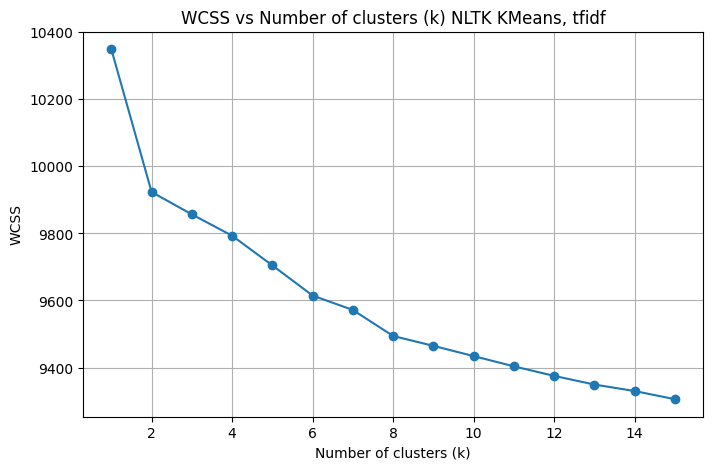

In [7]:
import matplotlib.pyplot as plt

# WCSS values from the provided data
ks = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
wcss = [
    10349.37, 9923.50, 9856.80, 9793.13, 9704.48,
    9614.66, 9571.60, 9494.00, 9464.62, 9434.08,
    9403.49, 9375.00, 9349.22, 9329.80, 9305.46
]

plt.figure(figsize=(8,5))
plt.plot(ks, wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('WCSS vs Number of clusters (k) - Custom TF-IDF')
plt.grid(True)
plt.show()

Our vocabulary is made of around 30k different words

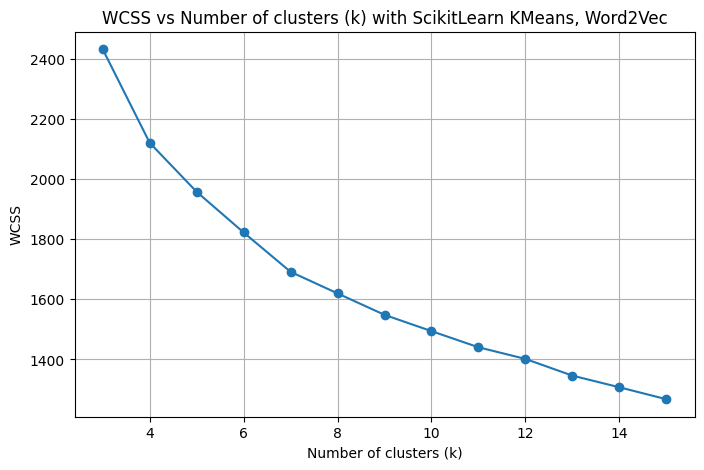

In [5]:
import matplotlib.pyplot as plt

ks = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
wcss = [
    2432.15, 2120.83, 1957.69, 1822.42, 1691.37,
    1619.59, 1548.24, 1494.04, 1440.36, 1401.50,
    1345.96, 1307.21, 1267.47
]
plt.figure(figsize=(8,5))
plt.plot(ks, wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('WCSS vs Number of clusters (k) with ScikitLearn KMeans, Word2Vec')
plt.grid(True)
plt.show()

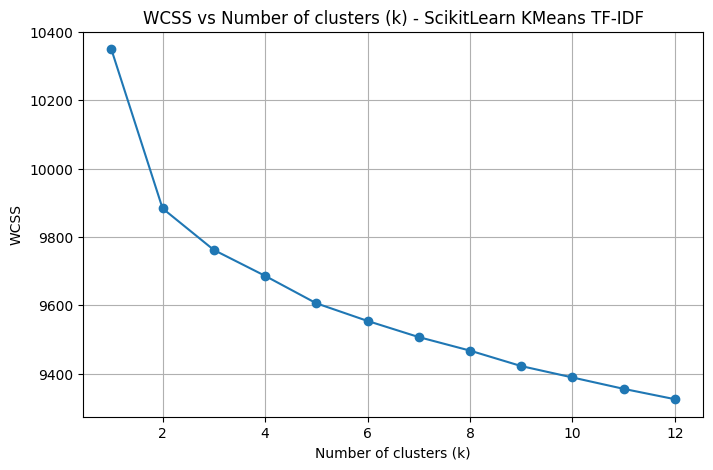

In [6]:
import matplotlib.pyplot as plt

# k values and WCSS from the results above
ks = [1,2,3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
wcss = [
    
    10349.37,9883.61,9762.12, 9686.39, 9606.08, 9554.43, 9507.17, 9467.58, 9422.33,9389.01,
    9355.67, 9325.38
]
plt.figure(figsize=(8,5))
plt.plot(ks, wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('WCSS vs Number of clusters (k) - ScikitLearn KMeans TF-IDF')
plt.grid(True)
plt.show()

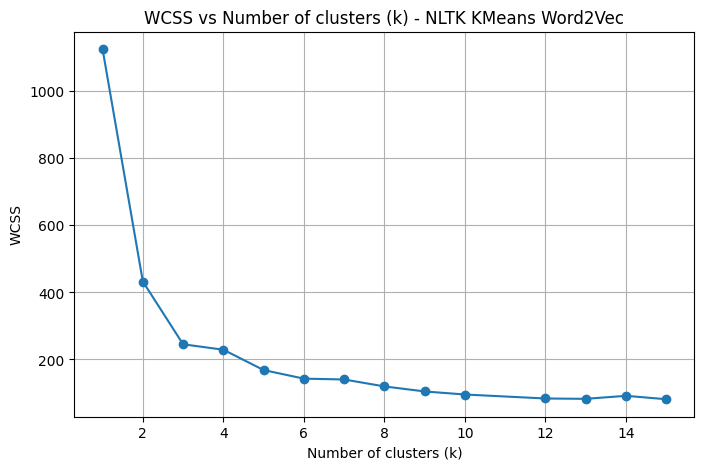

In [14]:
import matplotlib.pyplot as plt

# k values and corresponding WCSS from word2vec KMeans results
ks = [1, 2 ,3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15]
wcss = [1125.44, 432.43, 245.18, 228.98, 168.28, 142.71, 140.17, 119.49, 104.50, 95.36, 83.46, 82.47, 91.44, 81.30]
plt.figure(figsize=(8,5))
plt.plot(ks, wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('WCSS vs Number of clusters (k) - NLTK KMeans Word2Vec')
plt.grid(True)
plt.show()

In [8]:
import matplotlib.pyplot as plt

ks = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

wcss_tfidf_custom = [6621.30, 6560.36, 6546.90, 6517.24, 6518.21, 6490.48, 6483.49, 6478.66, 6467.10, 6461.94]
wcss_tfidf_sklearn = [8278.52, 7943.71, 7877.60, 7814.06, 7768.40, 7671.49, 7636.89, 7611.27, 7583.46, 7548.68]
wcss_word2vec = [4148.12, 2454.96, 1798.69, 1547.03, 1469.78, 1352.85, 1228.40, 1197.45, 1143.26, 1108.41]

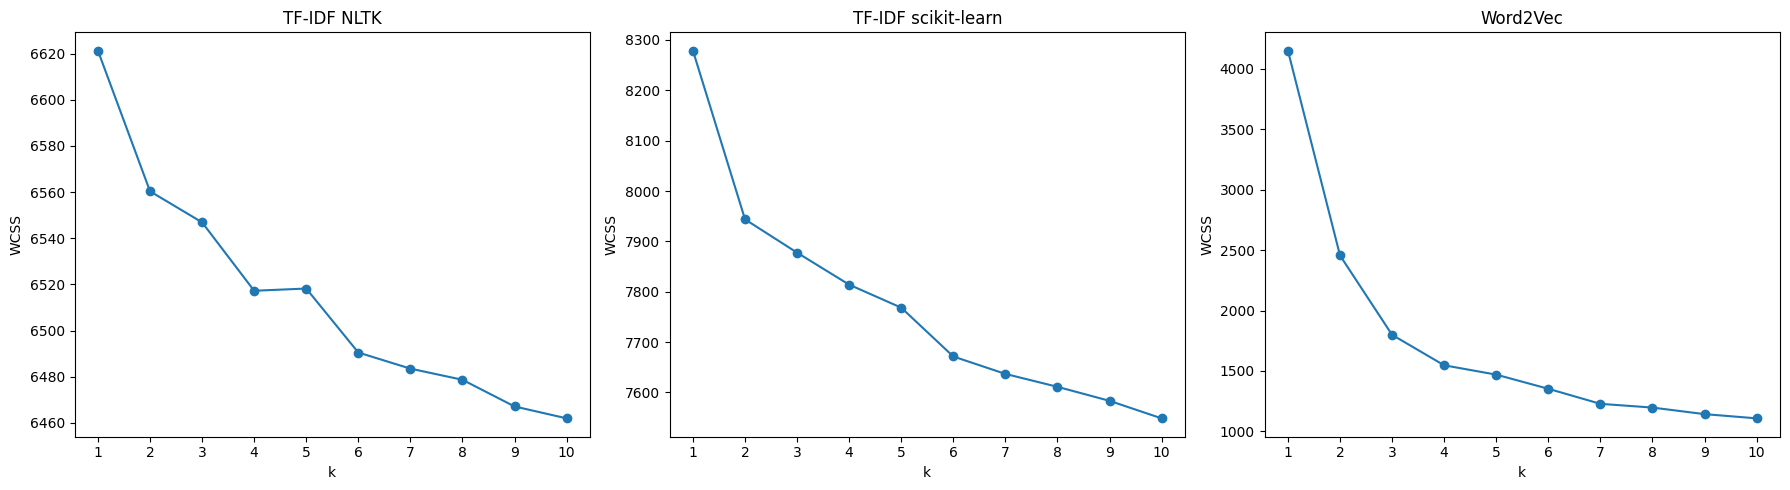

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, wcss, title in zip(axes, [wcss_tfidf_custom, wcss_tfidf_sklearn, wcss_word2vec],
                            ["Custom TF-IDF", "TF-IDF scikit-learn", "Word2Vec"]):
    ax.plot(ks, wcss, "o-")
    ax.set_xlabel("k")
    ax.set_ylabel("WCSS")
    ax.set_title(title)
    ax.set_xticks(ks)

plt.tight_layout()
plt.show()

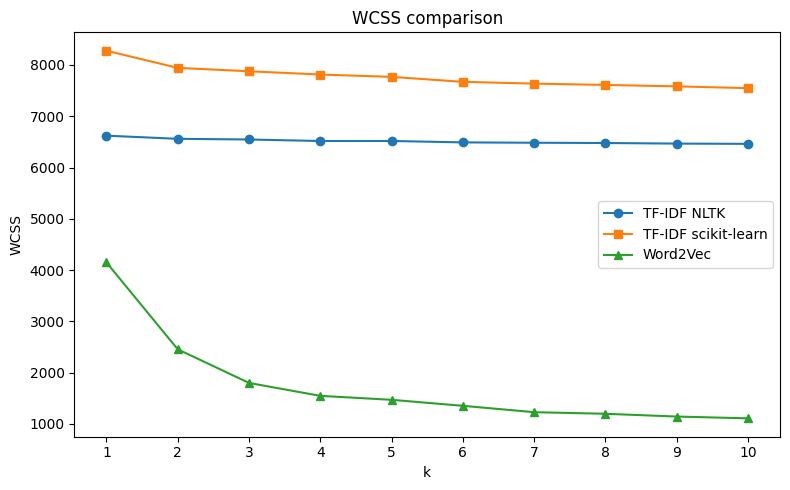

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(ks, wcss_tfidf_custom, "o-", label="Custom TF-IDF")
ax.plot(ks, wcss_tfidf_sklearn, "s-", label="TF-IDF scikit-learn")
ax.plot(ks, wcss_word2vec, "^-", label="Word2Vec")
ax.set_xlabel("k")
ax.set_ylabel("WCSS")
ax.set_title("WCSS comparison")
ax.set_xticks(ks)
ax.legend()

plt.tight_layout()
plt.show()